# Geographic Analysis
## Egyptian Market Distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

print('[OK] Libraries loaded successfully')

[OK] Libraries loaded successfully


## Load Data

In [2]:
orders_df = pd.read_csv('../mock_data/orders.csv', encoding='utf-8-sig')
print(f'Total Orders: {len(orders_df)}')

Total Orders: 2000


## Orders by Governorate

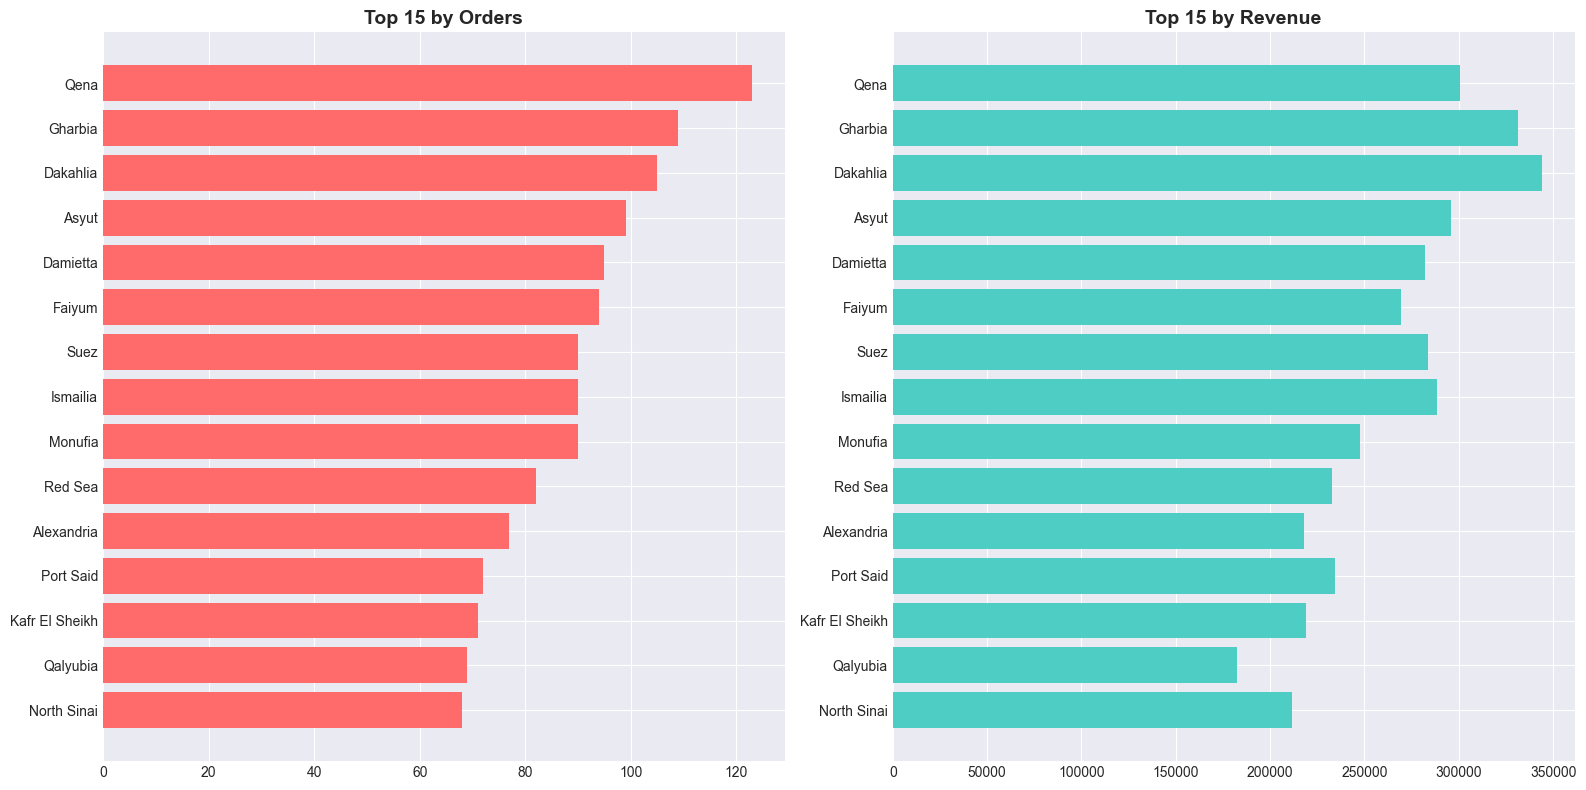

In [3]:
gov_stats = orders_df.groupby('shipping_governorate').agg({
    'order_id': 'count',
    'total_price_egp': 'sum'
}).reset_index().sort_values('order_id', ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.barh(range(len(gov_stats)), gov_stats['order_id'], color='#FF6B6B')
ax1.set_yticks(range(len(gov_stats)))
ax1.set_yticklabels(gov_stats['shipping_governorate'])
ax1.set_title('Top 15 by Orders', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

ax2.barh(range(len(gov_stats)), gov_stats['total_price_egp'], color='#4ECDC4')
ax2.set_yticks(range(len(gov_stats)))
ax2.set_yticklabels(gov_stats['shipping_governorate'])
ax2.set_title('Top 15 by Revenue', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()